In [104]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn.functional as F
from scipy.signal import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [110]:
collectedCSV  = glob("vctk/gen/csv/wav48_silence_trimmed/*/*.csv")
collectedFLAC = [csv.replace("vctk/gen/csv", "vctk/stock").replace("csv", "flac") for csv in collectedCSV]
Fs = 16000

In [ ]:
Ls = []
for flac_fn in tqdm(collectedFLAC):
    flacData, sr = torchaudio.load(flac_fn)
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    L = flacData.shape[-1]
    Ls.append(L)
maxLen = max(Ls)

In [ ]:
N = 200 # Sample 200 poitns for approximating the spectrum
gtSpec = torch.zeros(maxLen//2 + 1) # ground truth spectrum
mouseSpec = torch.zeros(maxLen//2 + 1) # mouse spectrum
pbar = tqdm(total=N)
for csv_fn, flac_fn in zip(collectedCSV[:N], collectedFLAC[:N]):
    _, X, _ = processFromFile(csv_fn, maxTimesteps= None)
    xsmooth = X
    
    flacData, sr = torchaudio.load(flac_fn)
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    gtX = flacData[0, :]
    
    # pad both until maxLen
    xsmooth = F.pad(xsmooth, (0, maxLen - xsmooth.shape[0]))
    gtX = F.pad(gtX, (0, maxLen - gtX.shape[0]))
    
    
    # normalize powers
    xsmooth = xsmooth / torch.sqrt(torch.sum(xsmooth ** 2))
    gtX = gtX / torch.sqrt(torch.sum(gtX ** 2))
    
    # compute FFTs
    xsmooth = torch.fft.rfft(xsmooth).abs()
    gtX = torch.fft.rfft(gtX).abs()
    
    # accumulate 
    gtSpec += gtX / N # divide here instead of outside the loop to avoid numerical issues (common when N is large)
    mouseSpec += xsmooth / N
    
    pbar.update(1)
pbar.close()

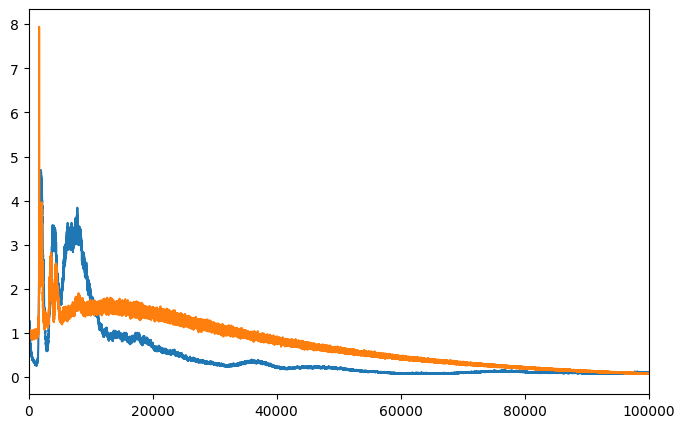

In [240]:
plt.figure(figsize=(8, 5))
plt.plot(gtSpec)
plt.plot(mouseSpec)
plt.xlim(0, 100000)


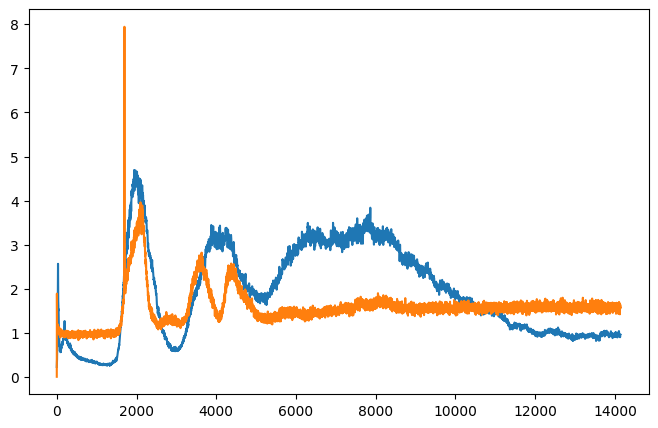

In [242]:

lowpass_cutoff_freq = 2000
lowpasslocation = int(lowpass_cutoff_freq * (maxLen//2+1) / Fs)

# Zoom on the lowpass region
plt.figure(figsize=(8, 5))
plt.plot(gtSpec[:lowpasslocation])
plt.plot(mouseSpec[:lowpasslocation])

In [181]:
def find_offset_for_maximal_correlation(signal_a, signal_b):
    """
    Returns the offset of signal_a in signal_b that maximizes the correlation between the two.
    """
    # make sure signal_a is shorter than signal_b, needed for the convolution filter
    if signal_a.shape[0] >= signal_b.shape[0]:
        signal_a, signal_b = signal_b, signal_a
    signal_a = signal_a.view(1, 1, -1)
    norm_a = torch.ones_like(signal_a)
    signal_b = signal_b.view(1, 1, -1)
    norm_b = torch.ones_like(signal_b)
    pad = signal_a.shape[-1] - 1
    correlation = F.conv1d(signal_b, signal_a, padding=pad).view(-1)
    norm_coeff = F.conv1d(norm_b, norm_a, padding=pad).view(-1)
    correlation = correlation / norm_coeff
    best_offset = torch.argmax(correlation)
    return best_offset.item()